# **Homework 5**
CWID: 20034297

In [21]:
# Import Necessary Libraries
import numpy as np
import matplotlib.pyplot as plt
import datetime
import gzip
import struct

## **Step 1: Generate 2D Data and Visualize**

In [22]:
# Generate data
np.random.seed(42)
data1 = np.random.normal(loc=1, scale=1, size=(100, 2))
data2 = np.random.normal(loc=5, scale=1, size=(100, 2))
data = np.vstack((data1, data2))

data.shape

(200, 2)

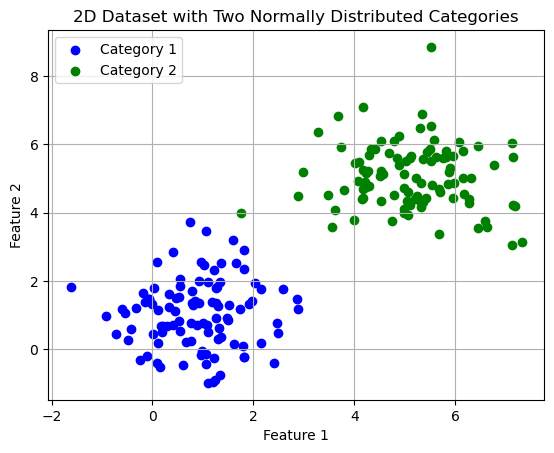

In [23]:
# First dataset
plt.scatter(data1[:,0],data1[:,1], color='blue',label='Category 1')

# Second data
plt.scatter(data2[:, 0], data2[:, 1], color = 'green', label = 'Category 2')

# Label for the x-axis representing Feature 1
plt.xlabel('Feature 1')

# Label for the y-axis representing Feature 2
plt.ylabel('Feature 2')

# Title of the plot
plt.title('2D Dataset with Two Normally Distributed Categories')

# Display the legend
plt.legend()

# Enable grid lines on the plot
plt.grid()

plt.show()

## **Step 2: Euclidean Distance and Initialize Centroids**

In [24]:
def euclidean_distance(a, b):
    return np.sqrt(np.sum((a - b) ** 2))

# def initialize_centroids(data, K):
#     indices = np.random.choice(data.shape[0], K, replace=False)
#     return data[indices]

def initialize_centroids (data, k) :
  # Initaialize k random centroids
  centroids_list = data[np.random.choice(data.shape[0], k, replace = False), :]
  return centroids_list


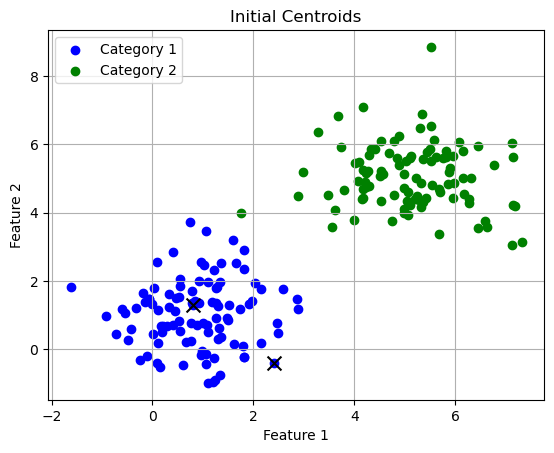

In [25]:
# Initialize centroids for k = 2 clusters
centroids = np.array(initialize_centroids(data, 2))

# Cluster 0
plt.scatter(data1[:, 0], data1[:, 1], color = 'blue', label = 'Category 1')

# Cluster 1
plt.scatter(data2[:, 0], data2[:, 1], color = 'green', label = 'Category 2')

# Plot the initial centroids as black 'x' markers with size 100
plt.scatter(centroids[:, 0], centroids[:, 1], 100, marker = 'x', color = 'black')

# Label for the x-axis representing Feature 1
plt.xlabel('Feature 1')

# Label for the y-axis representing Feature 2
plt.ylabel('Feature 2')

# Title of the plot
plt.title('Initial Centroids')

# Display the legend
plt.legend()

# Enable grid lines on the plot
plt.grid()

plt.show()

## **Step 3: Implement K-means Algorithm**

In [26]:
def assign_cluster(data, k, centroid_list):
    clusters = [[] for _ in range(k)]  # Reset clusters
    for b in data:
        distances = [euclidean_distance(a, b) for a in centroid_list]
        cluster_idx = np.argmin(distances)
        clusters[cluster_idx].append(b)
    return clusters

In [27]:
def update_centroid(k, clusters, centroid_list):
    prev_centroid = [c.copy() for c in centroid_list]  # Deep copy
    for i in range(k):
        if clusters[i]:  # Avoid empty cluster mean error
            centroid_list[i] = np.mean(clusters[i], axis=0)
    return centroid_list, prev_centroid

In [28]:
def K_Means(data, k):
    centroid_list = initialize_centroids(data, k)
    prev_centroid = None

    while prev_centroid is None or np.any(np.not_equal(centroid_list, prev_centroid)):
        clusters = assign_cluster(data, k, centroid_list)
        centroid_list, prev_centroid = update_centroid(k, clusters, centroid_list)

    print("Converged!")
    return clusters, centroid_list

Converged!


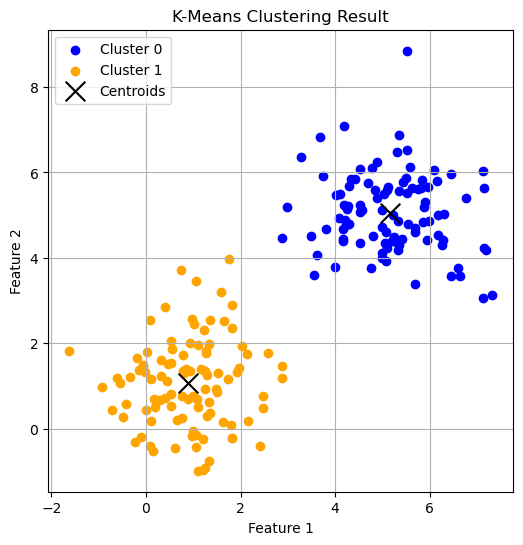

In [29]:
# K-Means clustering algorithm on 'data' with k = 2 clusters
clusters, centroids = K_Means(data, 2)

colors = ['blue', 'orange']
plt.figure(figsize=(6, 6))
for i, cluster in enumerate(clusters):
    if len(cluster) > 0:
        cluster = np.vstack(cluster)  # Ensure 2D array
        plt.scatter(cluster[:, 0], cluster[:, 1], color=colors[i], label=f'Cluster {i}')

centroids = np.array(centroids)
plt.scatter(centroids[:, 0], centroids[:, 1], s=200, marker='x', color='black', label='Centroids')

plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('K-Means Clustering Result')
plt.legend()
plt.grid()
plt.show()


## **Step 4: Train K-means on MNIST (Optional)**

In [ ]:
# imports
from sklearn.datasets import fetch_openml
from sklearn.cluster import KMeans
from datetime import datetime
import numpy as np

In [ ]:
def read_idx(filepath):
    with gzip.open(filepath, 'rb') as f:
        zero, data_type, dims = struct.unpack('>HBB', f.read(4))
        shape = tuple(struct.unpack('>I', f.read(4))[0] for _ in range(dims))
        return np.frombuffer(f.read(), dtype=np.uint8).reshape(shape)

In [32]:
# Base folder path for MNIST files
mnist_dir = './MNIST/'

# Load training and test datasets
train_img = read_idx(mnist_dir + 'train-images-idx3-ubyte.gz').copy()
y_train = read_idx(mnist_dir + 'train-labels-idx1-ubyte.gz').copy()
test_img = read_idx(mnist_dir + 't10k-images-idx3-ubyte.gz').copy()
y_test = read_idx(mnist_dir + 't10k-labels-idx1-ubyte.gz').copy()

# Print shapes to verify
print("Train Images:", train_img.shape)
print("Train Labels:", y_train.shape)
print("Test Images:", test_img.shape)
print("Test Labels:", y_test.shape)


Train Images: (60000, 28, 28)
Train Labels: (60000,)
Test Images: (10000, 28, 28)
Test Labels: (10000,)


In [33]:
# Flatten train images
X_train = train_img.reshape(train_img.shape[0], -1)  # (60000, 784)

# Flatten test images
X_test = test_img.reshape(test_img.shape[0], -1)     # (10000, 784)


In [34]:
# Set K = 10
k = 10

# Start timer
start_time = datetime.now()

# Train KMeans model
kmeans = KMeans(n_clusters=k, random_state=42)
kmeans.fit(X_train)

# End timer and print time taken
end_time = datetime.now()
print(f"KMeans training completed in: {end_time - start_time}")

# Optional: Print inertia
print("Inertia of the trained KMeans model:", kmeans.inertia_)

KMeans training completed in: 0:00:02.331305
Inertia of the trained KMeans model: 153017875601.06036


## **Step 5: Mini-Batch K-means on MNIST**

In [35]:
from sklearn.cluster import MiniBatchKMeans

k_values = [10, 16, 64, 256]
models = {}

for k in k_values:
    print(f"Training MiniBatchKMeans for K = {k}")
    mb_kmeans = MiniBatchKMeans(n_clusters=k, batch_size=1024, random_state=42)
    mb_kmeans.fit(X_train)
    models[k] = mb_kmeans
    print(f"Inertia for K={k}: {mb_kmeans.inertia_}")


Training MiniBatchKMeans for K = 10
Inertia for K=10: 155103498060.5722
Training MiniBatchKMeans for K = 16
Inertia for K=16: 143529788099.7182
Training MiniBatchKMeans for K = 64
Inertia for K=64: 117233222296.41339
Training MiniBatchKMeans for K = 256
Inertia for K=256: 97801282053.7327


### Choose best K (lowest inertia) and test

In [36]:
# Find K with lowest inertia
best_k = min(models, key=lambda k: models[k].inertia_)
best_model = models[best_k]

print(f"\nBest K based on lowest inertia: {best_k}")
print("Best model inertia:", best_model.inertia_)

# Predict cluster assignments for test set
predicted_clusters_test = best_model.predict(X_test)


Best K based on lowest inertia: 256
Best model inertia: 97801282053.7327


### Evaluate Clustering Accuracy

In [37]:
def assign_labels_to_clusters(clusters, true_labels, k):
    labels = np.zeros_like(clusters)
    for i in range(k):
        mask = (clusters == i)
        if np.any(mask):
            labels[mask] = np.bincount(true_labels[mask]).argmax()
    return labels

def manual_accuracy_score(true_labels, predicted_labels):
    correct_predictions = sum(p == t for p, t in zip(predicted_labels, true_labels))
    return correct_predictions / len(true_labels)

# Assign labels and compute accuracy
mapped_labels_test = assign_labels_to_clusters(predicted_clusters_test, y_test, best_k)
accuracy = manual_accuracy_score(y_test, mapped_labels_test)
print(f"Accuracy on test data with MiniBatchKMeans (K={best_k}): {accuracy:.4f}")

Accuracy on test data with MiniBatchKMeans (K=256): 0.8998
